# Engagement state vs trial mode (cluster use) along LDA 1

Exploratory first pass: does engaged/disengaged GLM-HMM state relate to which trial-mode (watershed) cluster a trial falls into, and does that relationship track the LDA 1 axis?

Data sources:
- Engagement states: `GLM-HMM/merged_behavioral_and_states.pqt` (see `load_states.ipynb`)
- Trial modes: `clustering/{n}_trial_waterclust`, produced by `3_trial_modes/clustering_trial_syllables_watershed.ipynb`
- LDA 1 axis: `clustering/mouse_LDA_5_bins_cut19-06-2026`

This will need to be rerun once the underlying pipeline is rerun on updated data - the cell below (`CLUSTER_FILES`, LDA/states filenames) is the single place to update filenames.

In [42]:
"""
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


In [43]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'

clustering_dir = prefix + 'clustering/'


def first_existing(*relative_paths):
    """First path (relative to prefix) that exists on this machine. Lets the notebook run
    unmodified on whichever machine has which vintage of a file cached locally."""
    for rel in relative_paths:
        if os.path.exists(prefix + rel):
            return rel
    raise FileNotFoundError(f'None of {relative_paths} found under {prefix}')


# Trial-mode (cluster) assignments at different clustering resolutions. All three come from the same
# (current) trial-sequence vintage (all_sequences_26-03-2026) and share a 244-session overlap with
# both the engagement states and the LDA 1 table - see clustering_trial_syllables_watershed.ipynb.
CLUSTER_FILES = ['12_trial_waterclust', '17_trial_waterclust', '22_trial_waterclust']

MIN_TRIALS_PER_CELL = 5  # a session x state x cluster cell needs >= this many trials to count towards occupancy


## Engagement state

Same derivation as `load_states.ipynb`: `dominant_state` from `p_state1 >= 0.5`. Note the state1/state2 -> engaged/disengaged mapping is a working label adopted in `load_states.ipynb`, not an independently validated fact - see that notebook's psychometric/chronometric checks.

In [44]:
states_df = pd.read_parquet(prefix + 'GLM-HMM/merged_behavioral_and_states.pqt')

right_correct = states_df['contrastLeft'].isna() & (states_df['rewarded'] == 1)
right_incorrect = states_df['contrastRight'].isna() & (states_df['rewarded'] == -1)
states_df['choice_right'] = (right_correct | right_incorrect).astype(int)
states_df['block'] = states_df['probabilityLeft']
states_df['dominant_state'] = np.where(states_df['p_state1'] >= 0.5, 'engaged', 'disengaged')

print(f"Animals: {states_df['animal'].nunique()}, sessions: {states_df['eid'].nunique()}, trials: {len(states_df)}")
states_df['dominant_state'].value_counts()


Animals: 139, sessions: 459, trials: 296090


dominant_state
engaged       248189
disengaged     47901
Name: count, dtype: int64

## Attach real trial IDs to states_df

`states_df` has no explicit `trial_id` - just row order within each session (`eid`). The trial-cluster files key trials by their real `trial_id` (parsed from the `sample` field). To recover it, we assume `states_df`'s Nth row within a session is literally raw trial index N (0-indexed), and match that directly against an `all_trials_*` file's own `trial_id` column - which trial(s) are missing from that file (first, last, or scattered) then doesn't matter, since we're matching by value, not by position. Validated per session by checking block / contrast / correct agreement before trusting the result; sessions that fail are left with `trial_id = NaN` rather than silently misaligned.

In [45]:
# Falls back to a locally-available all_trials_* file if the primary one isn't cached here.
# (verified: 4_mice/all_trials_04-05-2026 overlaps 307/308 sessions with the 12/17/22 cluster files,
# and gives 100% block/contrast/correct agreement on all of them via the value-matching below.)
TRIAL_FILE = first_existing('data/all_trials_06-07-2026', '4_mice/all_trials_04-05-2026')
print(f'Using TRIAL_FILE = {TRIAL_FILE}')


def attach_trial_id(states_df, trial_file=TRIAL_FILE, min_agreement=0.99):
    trials = pd.read_parquet(prefix + trial_file)
    sdf = states_df.copy()
    sdf['trial_id'] = sdf.groupby('eid').cumcount()

    merged = sdf.merge(
        trials[['session', 'trial_id', 'block', 'contrast', 'correct']]
              .rename(columns={'block': 'block_chk', 'contrast': 'contrast_chk', 'correct': 'correct_chk'}),
        left_on=['eid', 'trial_id'], right_on=['session', 'trial_id'], how='left')

    found = merged['contrast_chk'].notna()
    agree = ((merged['probabilityLeft'] == merged['block_chk'])
             & np.isclose(merged['signed_contrast'].abs(), merged['contrast_chk'].fillna(-1))
             & ((merged['rewarded'] == 1) == (merged['correct_chk'] == 1)))
    per_session = agree[found].groupby(merged.loc[found, 'eid']).mean()
    bad = per_session[per_session < min_agreement].index
    print(f'trial_id alignment: {len(per_session) - len(bad)}/{len(per_session)} sessions validated; '
          f'{len(bad)} rejected {list(bad[:3])}')
    merged.loc[merged['eid'].isin(bad), 'trial_id'] = np.nan
    return merged['trial_id'].values


states_df['trial_id'] = attach_trial_id(states_df)
print(f"Trials with a recovered trial_id: {states_df['trial_id'].notna().sum()} / {len(states_df)}")


Using TRIAL_FILE = 4_mice/all_trials_04-05-2026
trial_id alignment: 314/314 sessions validated; 0 rejected []
Trials with a recovered trial_id: 296090 / 296090


## Attach LDA 1 (per session)

In [46]:
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
states_df = states_df.merge(lda[['session', 'lda_1']], left_on='eid', right_on='session', how='left').drop(columns='session')

n_with_lda = states_df.loc[states_df['lda_1'].notna(), 'eid'].nunique()
print(f"Sessions with LDA 1: {n_with_lda} / {states_df['eid'].nunique()}")


Sessions with LDA 1: 244 / 459


## Load trial-cluster assignments and merge (per clustering resolution)

In [47]:
def load_cluster_df(filename):
    """Trial-cluster (trial-mode) assignments from clustering_trial_syllables_watershed.ipynb's
    watershed output. trial_id is recovered from `sample` (session + trial_id + trial_type), using
    the same numbering as attach_trial_id above. Unclustered/background trials (trial_cluster NaN,
    watershed label 0) are dropped."""
    df = pd.read_parquet(clustering_dir + filename, columns=['sample', 'session', 'mouse_name', 'trial_cluster'])
    df['trial_id'] = df['sample'].str.split().str[1:2].str.join('').astype(float)
    return df.dropna(subset=['trial_cluster'])[['session', 'trial_id', 'mouse_name', 'trial_cluster']]


merged = {}
n_clusters_by_file = {}
for f in CLUSTER_FILES:
    cluster_df = load_cluster_df(f)
    n_clusters = int(cluster_df['trial_cluster'].nunique())
    n_clusters_by_file[f] = n_clusters
    m = states_df.merge(cluster_df, left_on=['eid', 'trial_id'], right_on=['session', 'trial_id'], how='inner')
    merged[f] = m
    print(f"{f} ({n_clusters} clusters): {m['eid'].nunique()} sessions, {len(m)} trials merged "
          f"(cluster file has {cluster_df['session'].nunique()} sessions; states_df has {states_df['eid'].nunique()})")


12_trial_waterclust (12 clusters): 304 sessions, 182899 trials merged (cluster file has 308 sessions; states_df has 459)
17_trial_waterclust (18 clusters): 304 sessions, 183394 trials merged (cluster file has 308 sessions; states_df has 459)
22_trial_waterclust (23 clusters): 304 sessions, 183394 trials merged (cluster file has 308 sessions; states_df has 459)


## Cluster (trial-mode) usage by engagement state

For each session, occupancy = fraction of trials in each cluster, computed separately within engaged and disengaged trials. Session x state cells with fewer than `MIN_TRIALS_PER_CELL` trials are dropped before pooling across sessions.

In [48]:
def occupancy_by_state(m):
    counts = m.groupby(['eid', 'dominant_state', 'trial_cluster']).size().rename('n').reset_index()
    counts['total'] = counts.groupby(['eid', 'dominant_state'])['n'].transform('sum')
    counts = counts[counts['total'] >= MIN_TRIALS_PER_CELL].copy()
    counts['occupancy'] = counts['n'] / counts['total']
    return counts


occ = {f: occupancy_by_state(m) for f, m in merged.items()}


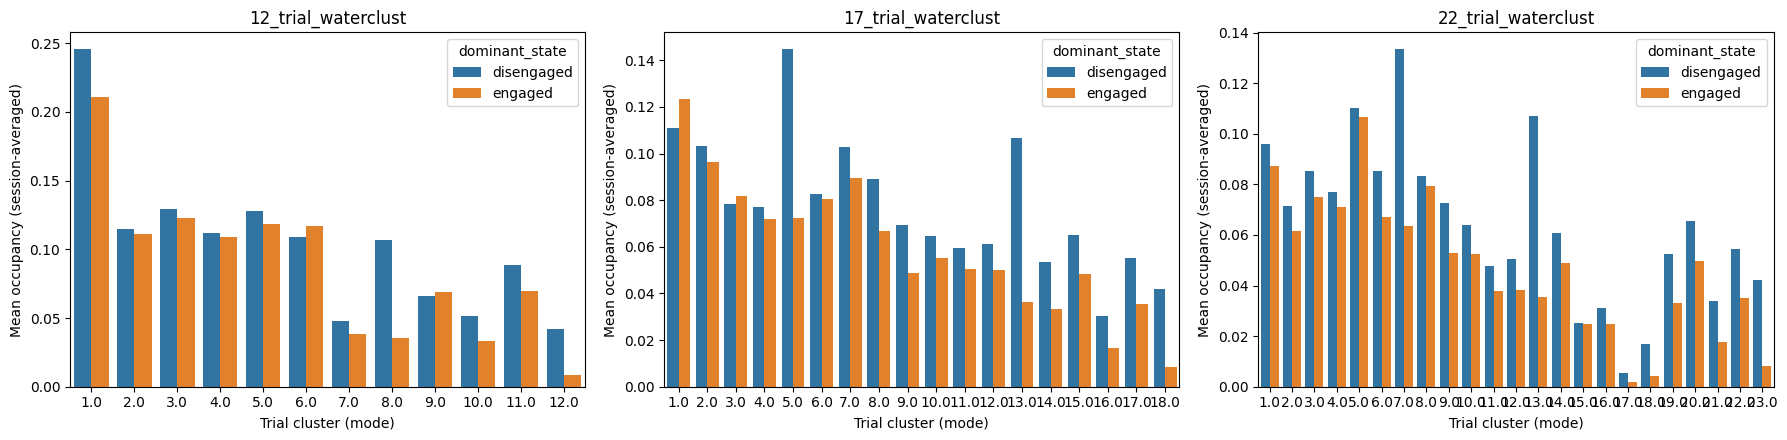

In [49]:
fig, axes = plt.subplots(1, len(CLUSTER_FILES), figsize=(6 * len(CLUSTER_FILES), 4.5))
for ax, f in zip(axes, CLUSTER_FILES):
    pooled = occ[f].groupby(['trial_cluster', 'dominant_state'])['occupancy'].mean().reset_index()
    sns.barplot(data=pooled, x='trial_cluster', y='occupancy', hue='dominant_state', ax=ax)
    ax.set_title(f)
    ax.set_xlabel('Trial cluster (mode)')
    ax.set_ylabel('Mean occupancy (session-averaged)')
plt.tight_layout()
plt.show()


### Same thing as pie charts

Same session-averaged occupancy as the bar plots above, one pie per state per clustering resolution, so the overall trial-mode "mix" for engaged vs disengaged trials can be compared at a glance.

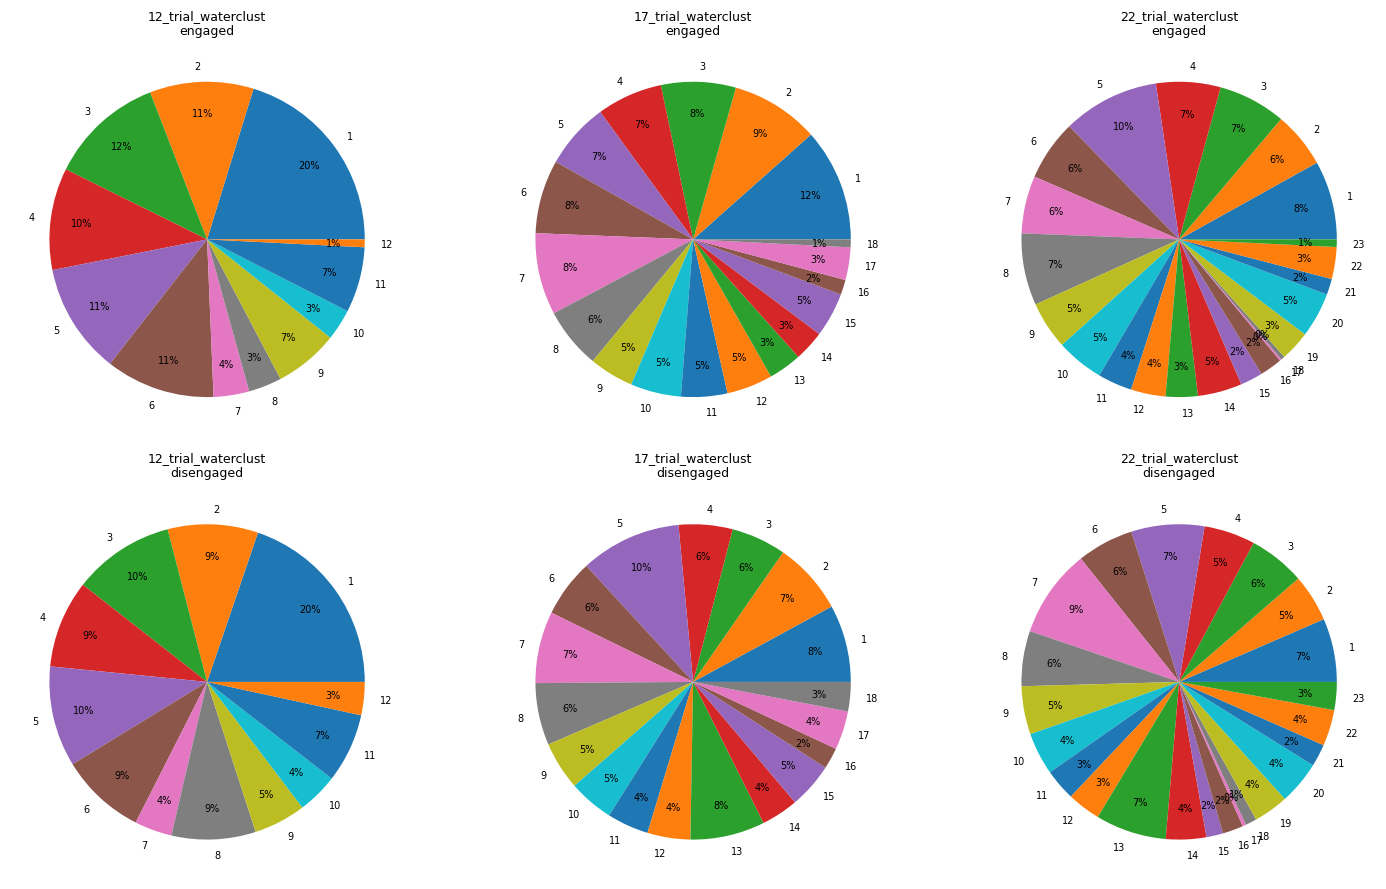

In [50]:
fig, axes = plt.subplots(2, len(CLUSTER_FILES), figsize=(5 * len(CLUSTER_FILES), 9))
for col, f in enumerate(CLUSTER_FILES):
    pooled = occ[f].groupby(['trial_cluster', 'dominant_state'])['occupancy'].mean().reset_index()
    for row, state in enumerate(['engaged', 'disengaged']):
        state_pooled = pooled[pooled['dominant_state'] == state].sort_values('trial_cluster')
        ax = axes[row, col]
        ax.pie(state_pooled['occupancy'], labels=state_pooled['trial_cluster'].astype(int),
               autopct='%1.0f%%', pctdistance=0.8, textprops={'fontsize': 7})
        ax.set_title(f'{f}\n{state}', fontsize=9)
plt.tight_layout()
plt.show()


## Does the engaged-vs-disengaged difference in cluster use relate to LDA 1?

Per session, summarize how different cluster usage is between engaged and disengaged trials as the L1 distance between their two occupancy vectors (0 = identical trial-mode usage in both states, 2 = fully disjoint). Correlate that per-session divergence against `lda_1`, separately for each clustering resolution, to see whether the pattern is robust to cluster granularity.

In [51]:
def state_divergence(occ_df):
    """L1 distance between per-cluster occupancy vectors for engaged vs disengaged trials, per
    session. Sessions missing one of the two states entirely (post min-trial filter) are excluded."""
    wide = occ_df.pivot_table(index=['eid', 'trial_cluster'], columns='dominant_state',
                               values='occupancy', fill_value=0)
    wide = wide.reindex(columns=['engaged', 'disengaged'], fill_value=0)
    has_both_states = occ_df.groupby('eid')['dominant_state'].nunique() == 2
    diff = (wide['engaged'] - wide['disengaged']).abs().groupby('eid').sum().rename('state_divergence')
    return diff[diff.index.isin(has_both_states[has_both_states].index)]


divergence = {}
for f in CLUSTER_FILES:
    div = state_divergence(occ[f]).reset_index()
    lda_lookup = merged[f][['eid', 'lda_1']].drop_duplicates('eid')
    div = div.merge(lda_lookup, on='eid').dropna(subset=['lda_1'])
    divergence[f] = div
    r_p, p_p = pearsonr(div['lda_1'], div['state_divergence'])
    r_s, p_s = spearmanr(div['lda_1'], div['state_divergence'])
    print(f"{f}: n={len(div)} sessions | Pearson r={r_p:.3f} (p={p_p:.4f}) | Spearman r={r_s:.3f} (p={p_s:.4f})")


12_trial_waterclust: n=229 sessions | Pearson r=0.116 (p=0.0808) | Spearman r=0.078 (p=0.2418)
17_trial_waterclust: n=230 sessions | Pearson r=0.107 (p=0.1070) | Spearman r=0.099 (p=0.1327)
22_trial_waterclust: n=230 sessions | Pearson r=0.116 (p=0.0795) | Spearman r=0.109 (p=0.0980)


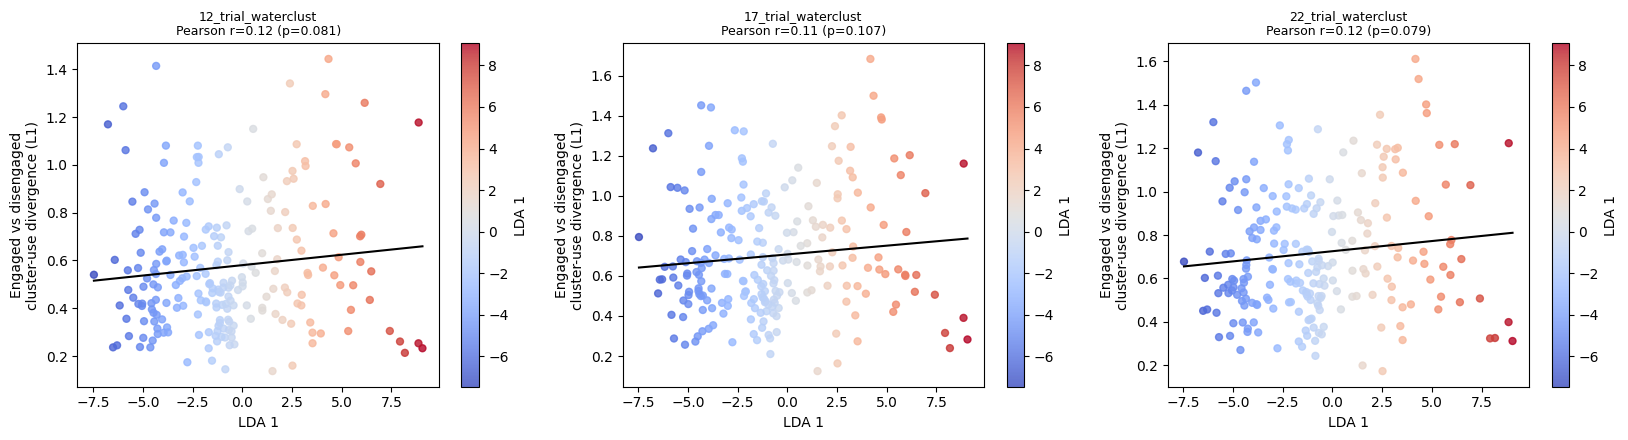

In [52]:
fig, axes = plt.subplots(1, len(CLUSTER_FILES), figsize=(5.5 * len(CLUSTER_FILES), 4.5))
for ax, f in zip(axes, CLUSTER_FILES):
    div = divergence[f]
    x, y = div['lda_1'], div['state_divergence']
    r, p = pearsonr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel('Engaged vs disengaged\ncluster-use divergence (L1)')
    ax.set_title(f"{f}\nPearson r={r:.2f} (p={p:.3f})", fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


## How entropic is cluster use, per session, along LDA 1? (engaged vs disengaged separately)

Rather than comparing engaged against disengaged directly (as above), this looks at each state on its own: for each session, the Shannon entropy of the cluster-occupancy distribution *within* engaged trials, and separately within disengaged trials - low entropy means a session sticks to a few trial modes in that state, high entropy means it spreads across many. Normalized by `log(n_clusters)` so the three clustering resolutions sit on the same 0-1 scale.

In [53]:
def entropy_by_state(occ_df, n_clusters):
    ent = (occ_df.groupby(['eid', 'dominant_state'])['occupancy']
                 .apply(lambda p: -(p * np.log(p)).sum())
                 .rename('entropy').reset_index())
    ent['normalized_entropy'] = ent['entropy'] / np.log(n_clusters)
    return ent


entropy_lda = {}
for f in CLUSTER_FILES:
    ent = entropy_by_state(occ[f], n_clusters_by_file[f])
    lda_lookup = merged[f][['eid', 'lda_1']].drop_duplicates('eid')
    ent = ent.merge(lda_lookup, on='eid').dropna(subset=['lda_1'])
    entropy_lda[f] = ent
    for state in ['engaged', 'disengaged']:
        sub = ent[ent['dominant_state'] == state]
        r_p, p_p = pearsonr(sub['lda_1'], sub['normalized_entropy'])
        r_s, p_s = spearmanr(sub['lda_1'], sub['normalized_entropy'])
        print(f"{f} | {state}: n={len(sub)} sessions | Pearson r={r_p:.3f} (p={p_p:.4f}) | "
              f"Spearman r={r_s:.3f} (p={p_s:.4f})")


12_trial_waterclust | engaged: n=244 sessions | Pearson r=0.020 (p=0.7566) | Spearman r=0.014 (p=0.8297)
12_trial_waterclust | disengaged: n=229 sessions | Pearson r=0.036 (p=0.5889) | Spearman r=0.159 (p=0.0161)
17_trial_waterclust | engaged: n=244 sessions | Pearson r=-0.177 (p=0.0056) | Spearman r=-0.174 (p=0.0064)
17_trial_waterclust | disengaged: n=230 sessions | Pearson r=-0.048 (p=0.4650) | Spearman r=0.036 (p=0.5877)
22_trial_waterclust | engaged: n=244 sessions | Pearson r=-0.068 (p=0.2921) | Spearman r=-0.045 (p=0.4822)
22_trial_waterclust | disengaged: n=230 sessions | Pearson r=-0.036 (p=0.5874) | Spearman r=0.050 (p=0.4540)


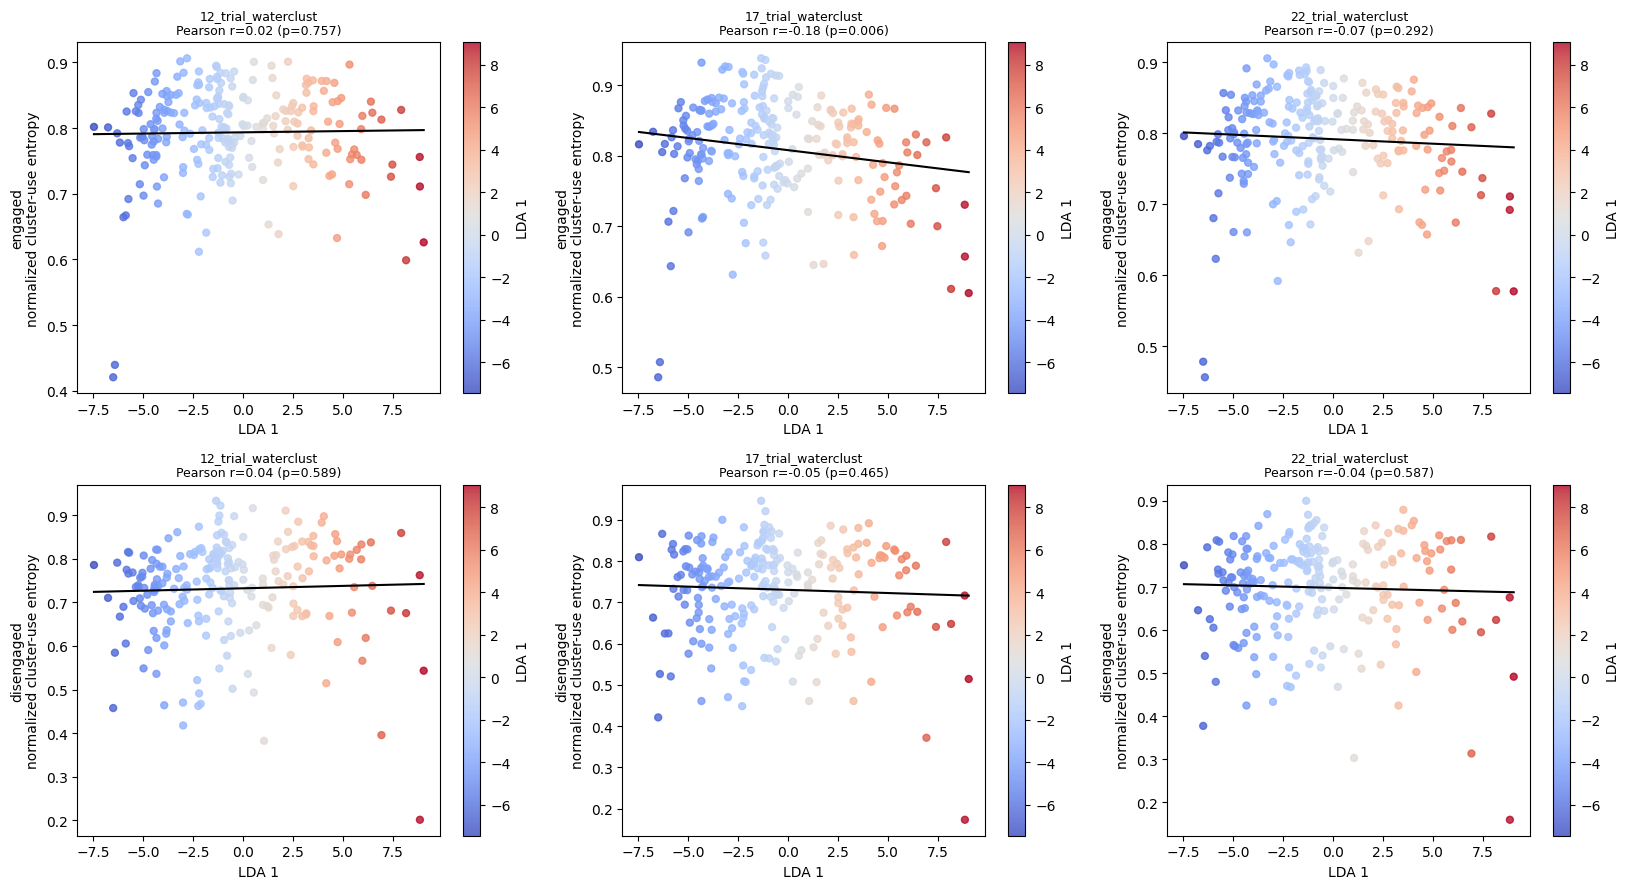

In [54]:
fig, axes = plt.subplots(2, len(CLUSTER_FILES), figsize=(5.5 * len(CLUSTER_FILES), 9))
for col, f in enumerate(CLUSTER_FILES):
    ent = entropy_lda[f]
    for row, state in enumerate(['engaged', 'disengaged']):
        sub = ent[ent['dominant_state'] == state]
        x, y = sub['lda_1'], sub['normalized_entropy']
        ax = axes[row, col]
        r, p = pearsonr(x, y)
        sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
        a, b = np.polyfit(x, y, 1)
        x_range = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
        ax.set_xlabel('LDA 1')
        ax.set_ylabel(f'{state}\nnormalized cluster-use entropy')
        ax.set_title(f"{f}\nPearson r={r:.2f} (p={p:.3f})", fontsize=9)
        fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


### Is that an engagement effect, or just cluster entropy vs LDA 1 in general?

Same entropy calculation, but now pooling engaged and disengaged trials together per session (state-blind), to check whether an LDA 1 relationship exists independently of engagement state at all - i.e. whether splitting by state above is actually adding information, or whether cluster entropy just tracks LDA 1 regardless of state.

In [55]:
def occupancy_overall(m):
    counts = m.groupby(['eid', 'trial_cluster']).size().rename('n').reset_index()
    counts['total'] = counts.groupby('eid')['n'].transform('sum')
    counts = counts[counts['total'] >= MIN_TRIALS_PER_CELL].copy()
    counts['occupancy'] = counts['n'] / counts['total']
    return counts


def entropy_overall(occ_df, n_clusters):
    ent = (occ_df.groupby('eid')['occupancy']
                 .apply(lambda p: -(p * np.log(p)).sum())
                 .rename('entropy').reset_index())
    ent['normalized_entropy'] = ent['entropy'] / np.log(n_clusters)
    return ent


entropy_overall_lda = {}
for f in CLUSTER_FILES:
    occ_all = occupancy_overall(merged[f])
    ent = entropy_overall(occ_all, n_clusters_by_file[f])
    lda_lookup = merged[f][['eid', 'lda_1']].drop_duplicates('eid')
    ent = ent.merge(lda_lookup, on='eid').dropna(subset=['lda_1'])
    entropy_overall_lda[f] = ent
    r_p, p_p = pearsonr(ent['lda_1'], ent['normalized_entropy'])
    r_s, p_s = spearmanr(ent['lda_1'], ent['normalized_entropy'])
    print(f"{f} | state-independent: n={len(ent)} sessions | Pearson r={r_p:.3f} (p={p_p:.4f}) | "
          f"Spearman r={r_s:.3f} (p={p_s:.4f})")


12_trial_waterclust | state-independent: n=244 sessions | Pearson r=0.054 (p=0.4036) | Spearman r=0.061 (p=0.3451)
17_trial_waterclust | state-independent: n=244 sessions | Pearson r=-0.146 (p=0.0223) | Spearman r=-0.140 (p=0.0284)
22_trial_waterclust | state-independent: n=244 sessions | Pearson r=-0.039 (p=0.5399) | Spearman r=-0.009 (p=0.8931)


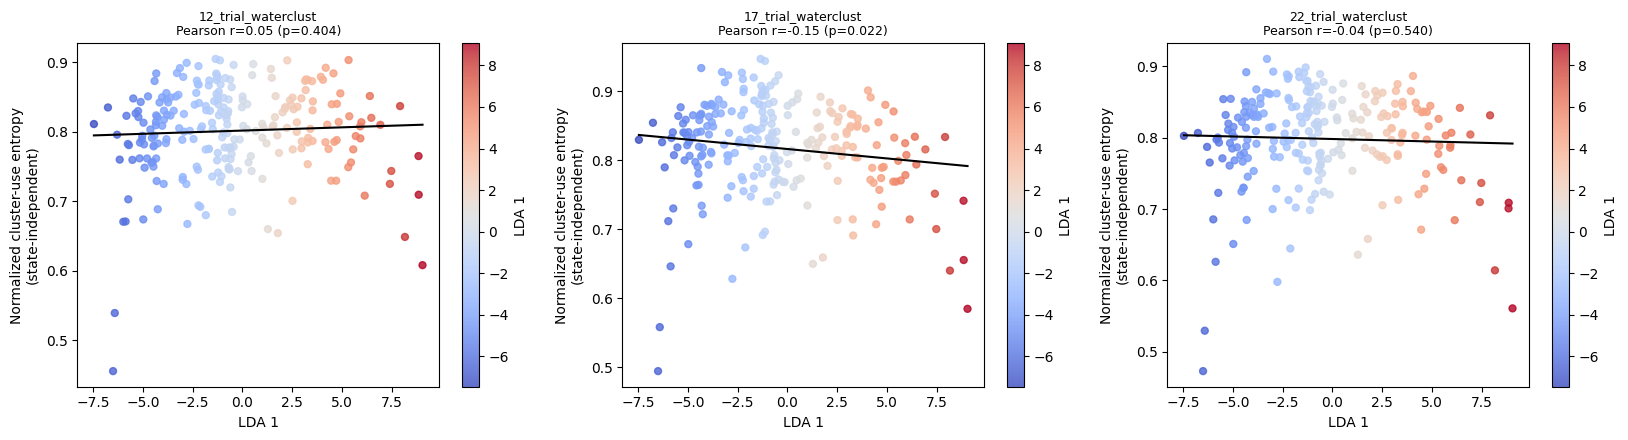

In [56]:
fig, axes = plt.subplots(1, len(CLUSTER_FILES), figsize=(5.5 * len(CLUSTER_FILES), 4.5))
for ax, f in zip(axes, CLUSTER_FILES):
    ent = entropy_overall_lda[f]
    x, y = ent['lda_1'], ent['normalized_entropy']
    r, p = pearsonr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel('Normalized cluster-use entropy\n(state-independent)')
    ax.set_title(f"{f}\nPearson r={r:.2f} (p={p:.3f})", fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


## State switching and trial clusters

Motivated by a known result: mice higher on LDA 1 switch less between engaged and disengaged states. Two follow-ups from here, both restricted to `17_trial_waterclust` (the resolution where the entropy/divergence effects above actually showed up):

1. Are the LDA 1 relationships found above just a switching-frequency confound (fewer switches -> longer, cleaner within-state runs -> less noisy occupancy/entropy estimates), rather than a real trial-mode effect?
2. Does the same "stickiness" that shows up in engagement state also show up in trial-cluster sequences themselves - i.e. do high-LDA-1 mice also stay in the same trial mode for longer stretches, baseline-corrected for how concentrated their cluster usage already is?

### 1. Controlling for switching frequency (n_transitions)

`n_transitions` = number of trial-to-trial engaged/disengaged switches per session, computed from the full `states_df` (not just clustered trials, so it isn't itself biased by which trials got a cluster). Each LDA-1 relationship found above is reported both raw and after partialling out `n_transitions` from both variables (same residualization approach as `load_states.ipynb`).

In [57]:
FOCUS_FILE = '17_trial_waterclust'


def n_transitions_per_session(states_df):
    sdf = states_df.dropna(subset=['trial_id']).sort_values(['eid', 'trial_id'])
    n_trans = sdf.groupby('eid')['dominant_state'].apply(lambda s: (s.values[1:] != s.values[:-1]).sum())
    return n_trans.rename('n_transitions').reset_index()


def residualize(y, x):
    a, b = np.polyfit(x, y, 1)
    return y - (a * x + b)


def partial_corr_report(df, y_col, label):
    d = df.merge(n_transitions, on='eid').dropna(subset=[y_col, 'lda_1', 'n_transitions'])
    r_raw, p_raw = pearsonr(d['lda_1'], d[y_col])
    y_resid = residualize(d[y_col], d['n_transitions'])
    x_resid = residualize(d['lda_1'], d['n_transitions'])
    r_partial, p_partial = pearsonr(x_resid, y_resid)
    print(f"{label}: n={len(d)} | raw r={r_raw:.3f} (p={p_raw:.4f}) -> partialling out n_transitions: "
          f"r={r_partial:.3f} (p={p_partial:.4f})")


n_transitions = n_transitions_per_session(states_df)

partial_corr_report(divergence[FOCUS_FILE], 'state_divergence', 'Engaged-vs-disengaged divergence')
partial_corr_report(entropy_lda[FOCUS_FILE].query("dominant_state == 'engaged'"),
                     'normalized_entropy', 'Engaged-trial entropy')
partial_corr_report(entropy_lda[FOCUS_FILE].query("dominant_state == 'disengaged'"),
                     'normalized_entropy', 'Disengaged-trial entropy')
partial_corr_report(entropy_overall_lda[FOCUS_FILE], 'normalized_entropy', 'State-independent entropy')


Engaged-vs-disengaged divergence: n=230 | raw r=0.107 (p=0.1070) -> partialling out n_transitions: r=-0.003 (p=0.9634)
Engaged-trial entropy: n=244 | raw r=-0.177 (p=0.0056) -> partialling out n_transitions: r=-0.171 (p=0.0076)
Disengaged-trial entropy: n=230 | raw r=-0.048 (p=0.4650) -> partialling out n_transitions: r=0.001 (p=0.9832)
State-independent entropy: n=244 | raw r=-0.146 (p=0.0223) -> partialling out n_transitions: r=-0.155 (p=0.0156)


### 2. Trial-cluster stickiness, corrected for a shuffle null

Per session, the observed trial-to-trial cluster self-transition probability `P(cluster_t+1 = cluster_t)`, compared against a null built by shuffling that session's own cluster labels (same per-cluster frequencies, no temporal structure) - so a session that's "sticky" merely because one cluster dominates doesn't look falsely sticky. `stickiness_excess = observed - null_mean` is the baseline-corrected metric.

In [58]:
def self_transition_prob(labels):
    if len(labels) < 2:
        return np.nan
    return np.mean(labels[1:] == labels[:-1])


def stickiness_with_null(m, n_shuffles=200, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for eid, g in m.dropna(subset=['trial_id']).sort_values('trial_id').groupby('eid'):
        labels = g['trial_cluster'].values
        if len(labels) < 10:
            continue
        observed = self_transition_prob(labels)
        null_vals = np.array([self_transition_prob(rng.permutation(labels)) for _ in range(n_shuffles)])
        rows.append({'eid': eid, 'observed': observed, 'null_mean': null_vals.mean(),
                     'null_std': null_vals.std(), 'n_trials': len(labels)})
    out = pd.DataFrame(rows)
    out['stickiness_excess'] = out['observed'] - out['null_mean']
    out['stickiness_z'] = out['stickiness_excess'] / out['null_std'].replace(0, np.nan)
    return out


cluster_stickiness = stickiness_with_null(merged[FOCUS_FILE])
lda_lookup = merged[FOCUS_FILE][['eid', 'lda_1']].drop_duplicates('eid')
cluster_stickiness = cluster_stickiness.merge(lda_lookup, on='eid').dropna(subset=['lda_1'])

for col in ['observed', 'stickiness_excess', 'stickiness_z']:
    r_p, p_p = pearsonr(cluster_stickiness['lda_1'], cluster_stickiness[col])
    r_s, p_s = spearmanr(cluster_stickiness['lda_1'], cluster_stickiness[col])
    print(f"{col}: n={len(cluster_stickiness)} | Pearson r={r_p:.3f} (p={p_p:.4f}) | "
          f"Spearman r={r_s:.3f} (p={p_s:.4f})")


observed: n=244 | Pearson r=0.150 (p=0.0193) | Spearman r=0.174 (p=0.0063)
stickiness_excess: n=244 | Pearson r=0.155 (p=0.0156) | Spearman r=0.135 (p=0.0346)
stickiness_z: n=244 | Pearson r=0.098 (p=0.1271) | Spearman r=0.115 (p=0.0728)


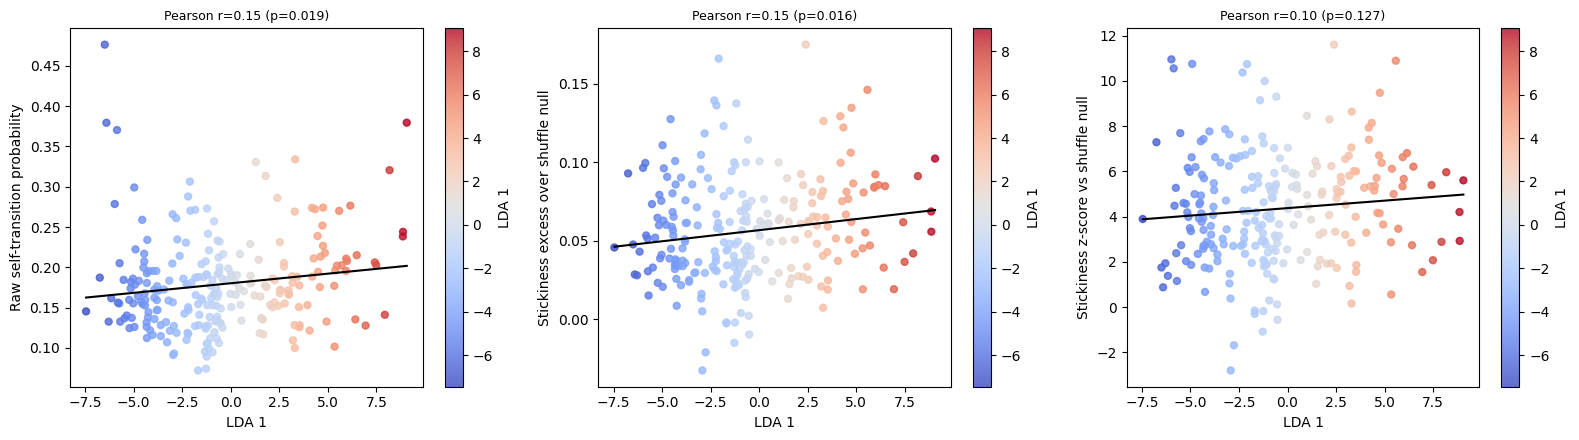

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, label in [(axes[0], 'observed', 'Raw self-transition probability'),
                        (axes[1], 'stickiness_excess', 'Stickiness excess over shuffle null'),
                        (axes[2], 'stickiness_z', 'Stickiness z-score vs shuffle null')]:
    x, y = cluster_stickiness['lda_1'], cluster_stickiness[col]
    r, p = pearsonr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel(label)
    ax.set_title(f"Pearson r={r:.2f} (p={p:.3f})", fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


### Session sequences: engagement state and trial cluster, side by side

Two aligned strips per session - engagement state (top) and trial-mode cluster (bottom), trial by trial - for a few long sessions from mice at the low and high ends of LDA 1, to see the switching-frequency difference directly alongside cluster usage. Only trials with both a state and a cluster assignment are shown, so gaps from unclustered (background) trials are skipped.

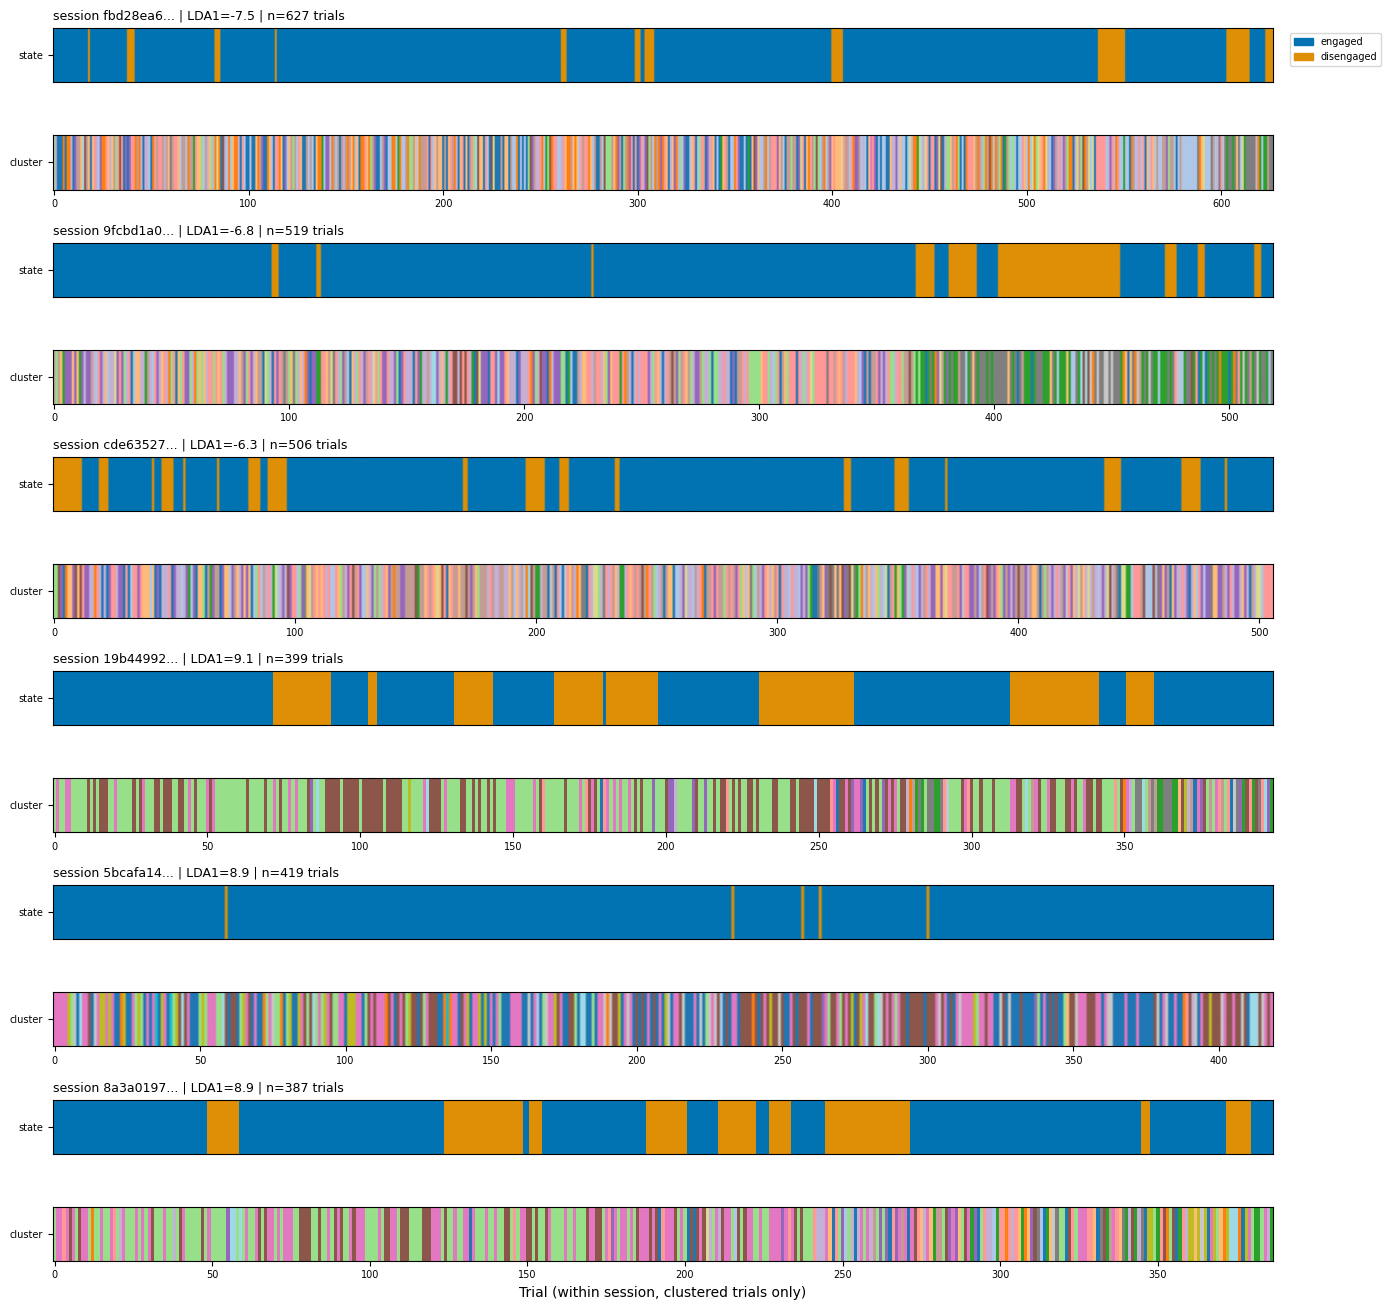

In [60]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

demo_source = merged[FOCUS_FILE].dropna(subset=['lda_1', 'trial_id']).copy()
session_summary = (demo_source.groupby('eid')
                    .agg(lda_1=('lda_1', 'first'), n_trials=('trial_id', 'size'))
                    .reset_index())
session_summary = session_summary[session_summary['n_trials'] >= 200]

N_DEMO = 3
demo_sessions = (session_summary.sort_values('lda_1').head(N_DEMO)['eid'].tolist()
                  + session_summary.sort_values('lda_1', ascending=False).head(N_DEMO)['eid'].tolist())

STATE_TO_IDX = {'engaged': 0, 'disengaged': 1}
state_cmap = ListedColormap(['#0173B2', '#DE8F05'])
unique_clusters = sorted(demo_source['trial_cluster'].dropna().unique())
cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}
cluster_cmap = plt.get_cmap('tab20', len(unique_clusters))

fig, axes = plt.subplots(2 * len(demo_sessions), 1, figsize=(14, 1.1 * len(demo_sessions) * 2))
for i, eid in enumerate(demo_sessions):
    sess = demo_source[demo_source['eid'] == eid].sort_values('trial_id')
    lda_val = sess['lda_1'].iloc[0]
    state_row = sess['dominant_state'].map(STATE_TO_IDX).values[None, :]
    cluster_row = sess['trial_cluster'].map(cluster_to_idx).values[None, :]

    ax_state, ax_cluster = axes[2 * i], axes[2 * i + 1]
    ax_state.imshow(state_row, aspect='auto', cmap=state_cmap, vmin=0, vmax=1)
    ax_state.set_yticks([0])
    ax_state.set_yticklabels(['state'], fontsize=7)
    ax_state.set_xticks([])
    ax_state.set_title(f'session {eid[:8]}... | LDA1={lda_val:.1f} | n={sess.shape[0]} trials',
                        fontsize=9, loc='left')

    ax_cluster.imshow(cluster_row, aspect='auto', cmap=cluster_cmap, vmin=0, vmax=len(unique_clusters) - 1)
    ax_cluster.set_yticks([0])
    ax_cluster.set_yticklabels(['cluster'], fontsize=7)
    ax_cluster.tick_params(axis='x', labelsize=7)

axes[-1].set_xlabel('Trial (within session, clustered trials only)')
state_patches = [mpatches.Patch(color=state_cmap(v), label=k) for k, v in STATE_TO_IDX.items()]
axes[0].legend(handles=state_patches, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7)
plt.tight_layout()
plt.show()


## Visualizing trial-mode entropy: rank-abundance curves by LDA 1 tertile

Rather than reducing cluster usage to a single entropy number, a rank-abundance curve (occupancy sorted from most- to least-used cluster) shows the *shape* of concentration directly - a curve that drops fast and flattens near zero means a session leans on a couple of trial modes; a flat curve means usage is spread out. Sessions are split into LDA 1 tertiles (`lda_group`) so the shape difference across the LDA 1 axis is visible at a glance.

(A follow-up on whether the engagement posterior itself "splits" more cleanly for high-LDA-1 mice - the other half of this question - is parked for now.)

In [61]:
lda_group_lookup = (states_df[['eid', 'lda_1']].drop_duplicates('eid').dropna(subset=['lda_1']).copy())
lda_group_lookup['lda_group'] = pd.qcut(lda_group_lookup['lda_1'], 3,
                                         labels=['Low LDA1', 'Mid LDA1', 'High LDA1'])
LDA_GROUP_ORDER = ['Low LDA1', 'Mid LDA1', 'High LDA1']
LDA_GROUP_COLORS = {'Low LDA1': 'tab:blue', 'Mid LDA1': 'gray', 'High LDA1': 'tab:red'}


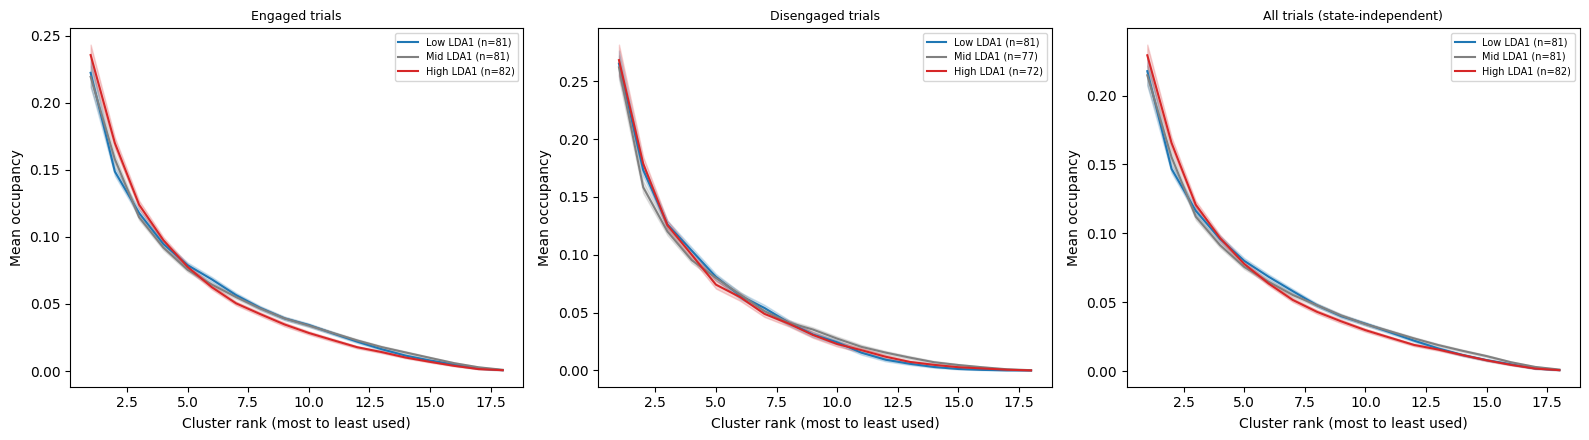

In [62]:
def rank_abundance(occ_df, n_clusters):
    """Per-session cluster occupancy, sorted descending and zero-padded to n_clusters, so sessions
    using fewer distinct clusters still compare directly by rank rather than by cluster identity."""
    curves = {}
    for eid, g in occ_df.groupby('eid'):
        vals = np.sort(g['occupancy'].values)[::-1]
        padded = np.zeros(n_clusters)
        padded[:len(vals)] = vals
        curves[eid] = padded
    return pd.DataFrame(curves).T


def plot_rank_abundance(ax, occ_df, n_clusters, title):
    curves = rank_abundance(occ_df, n_clusters).merge(
        lda_group_lookup.set_index('eid')[['lda_group']], left_index=True, right_index=True)
    ranks = np.arange(1, n_clusters + 1)
    for group in LDA_GROUP_ORDER:
        sub = curves[curves['lda_group'] == group].drop(columns='lda_group')
        mean_curve, sem_curve = sub.mean(axis=0), sub.sem(axis=0)
        ax.plot(ranks, mean_curve, label=f'{group} (n={len(sub)})', color=LDA_GROUP_COLORS[group])
        ax.fill_between(ranks, mean_curve - sem_curve, mean_curve + sem_curve,
                         alpha=0.2, color=LDA_GROUP_COLORS[group])
    ax.set_xlabel('Cluster rank (most to least used)')
    ax.set_ylabel('Mean occupancy')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)


n_clusters_focus = n_clusters_by_file[FOCUS_FILE]
occ_overall_focus = occupancy_overall(merged[FOCUS_FILE])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_rank_abundance(axes[0], occ[FOCUS_FILE].query("dominant_state == 'engaged'"),
                     n_clusters_focus, 'Engaged trials')
plot_rank_abundance(axes[1], occ[FOCUS_FILE].query("dominant_state == 'disengaged'"),
                     n_clusters_focus, 'Disengaged trials')
plot_rank_abundance(axes[2], occ_overall_focus, n_clusters_focus, 'All trials (state-independent)')
plt.tight_layout()
plt.show()


## Does posterior confidence relate to trial-cluster entropy directly?

Rank sessions by their overall posterior confidence - mean of `max(p_state1, p_state2)` across all trials in the session, from the full `states_df` - and correlate that against trial-cluster-use entropy (engaged, disengaged, and state-independent, `FOCUS_FILE` = `17_trial_waterclust`). This tests the bridge directly, without going through LDA 1 at all: are more confidently-classified sessions also more concentrated in trial-mode use?

In [63]:
session_confidence = (states_df.assign(confidence=np.maximum(states_df['p_state1'], states_df['p_state2']))
                       .groupby('eid')['confidence'].mean()
                       .rename('mean_confidence').reset_index())
session_confidence['confidence_rank'] = session_confidence['mean_confidence'].rank()

confidence_entropy = {}
for state_label, ent_table in [('engaged', entropy_lda[FOCUS_FILE].query("dominant_state == 'engaged'")),
                                ('disengaged', entropy_lda[FOCUS_FILE].query("dominant_state == 'disengaged'")),
                                ('state-independent', entropy_overall_lda[FOCUS_FILE])]:
    d = ent_table.merge(session_confidence, on='eid').dropna(subset=['normalized_entropy'])
    confidence_entropy[state_label] = d
    r_p, p_p = pearsonr(d['mean_confidence'], d['normalized_entropy'])
    r_s, p_s = spearmanr(d['confidence_rank'], d['normalized_entropy'])
    print(f"{state_label}: n={len(d)} | Pearson r={r_p:.3f} (p={p_p:.4f}) | "
          f"Spearman (rank) r={r_s:.3f} (p={p_s:.4f})")


engaged: n=244 | Pearson r=-0.035 (p=0.5909) | Spearman (rank) r=-0.061 (p=0.3442)
disengaged: n=230 | Pearson r=-0.349 (p=0.0000) | Spearman (rank) r=-0.333 (p=0.0000)
state-independent: n=244 | Pearson r=-0.024 (p=0.7041) | Spearman (rank) r=-0.061 (p=0.3437)


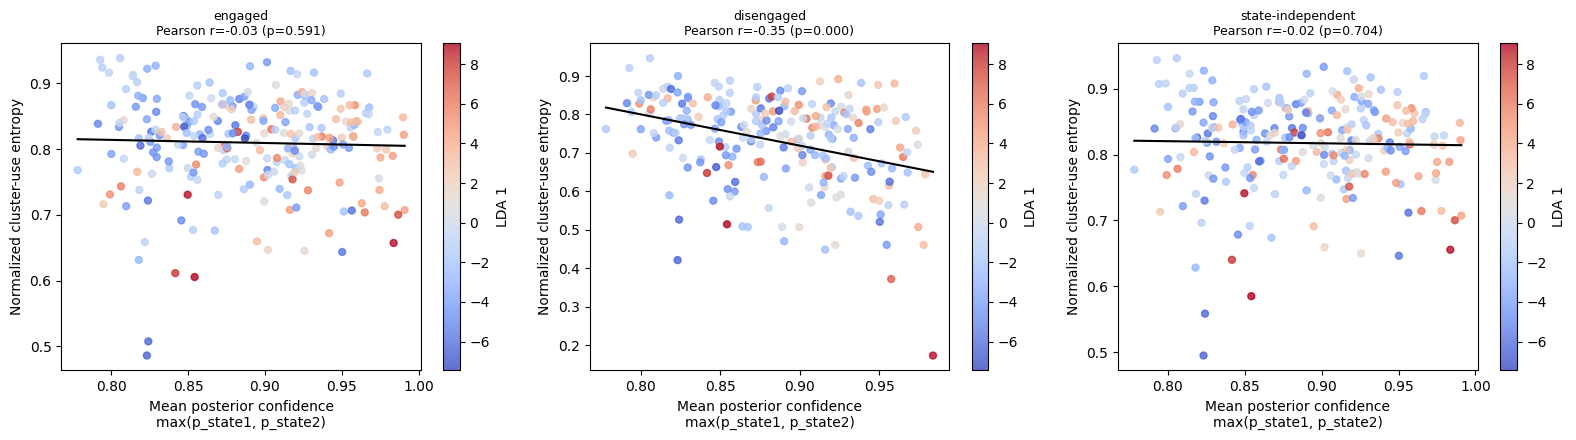

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, state_label in zip(axes, ['engaged', 'disengaged', 'state-independent']):
    d = confidence_entropy[state_label]
    x, y = d['mean_confidence'], d['normalized_entropy']
    r, p = pearsonr(x, y)
    sc = ax.scatter(x, y, c=d['lda_1'], cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.set_xlabel('Mean posterior confidence\nmax(p_state1, p_state2)')
    ax.set_ylabel('Normalized cluster-use entropy')
    ax.set_title(f"{state_label}\nPearson r={r:.2f} (p={p:.3f})", fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


## Trial-mode fingerprints: engaged vs disengaged

Adapted from the "Trial modes" section of `clustering/Analyses/fingerprint_analyses_mice.ipynb` (despite the filename, that notebook has the reference code for this plot). For each trial cluster, this shows the raw syllable sequence across the trial (Pre-quiescence / Quiescence / Choice / ITI, 10 time-bins each), one row per trial, trials sorted for visual grouping - a direct look at *what a trial mode actually looks like*, rather than just a cluster ID. Colour groups by paw state (8 hues) with whisking/licking combo as a shade within each hue, same design as the original notebook's `palette_16`.

Extending the original single-panel-per-cluster figure: here each cluster gets **two** rows - engaged trials on top, disengaged trials below - using the same colour scale (`vmin=0, vmax=31`) so panels are directly comparable.

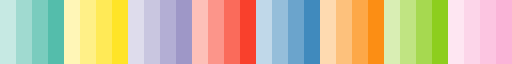

In [65]:
from matplotlib.colors import ListedColormap, to_rgb, to_hex

EPOCHS_TO_ANALYSE = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
N_BINS_PER_EPOCH = 10

# Which cluster resolution to visualize fingerprints for (any of CLUSTER_FILES).
FINGERPRINT_CLUSTER_FILE = CLUSTER_FILES[0]

# raw binned_sequence codes encode paw_state(0-7) + 8*whisking(0/1) + 16*licking(0/1)
RAW_CODE_TO_LABEL = {
    0: '000', 1: '100', 2: '200', 3: '300', 4: '400', 5: '500', 6: '600', 7: '700',
    8: '010', 9: '110', 10: '210', 11: '310', 12: '410', 13: '510', 14: '610', 15: '710',
    16: '001', 17: '101', 18: '201', 19: '301', 20: '401', 21: '501', 22: '601', 23: '701',
    24: '011', 25: '111', 26: '211', 27: '311', 28: '411', 29: '511', 30: '611', 31: '711',
}
# same labels, reordered by paw state (outer, 8 groups) then whisk/lick combo (inner, 4 shades) -
# matches fingerprint_analyses_mice.ipynb's identifiable_mapping, used to line labels up with palette_16
LABEL_TO_GROUPED_CODE = {
    '000': 0, '010': 1, '001': 2, '011': 3,
    '100': 4, '110': 5, '101': 6, '111': 7,
    '200': 8, '210': 9, '201': 10, '211': 11,
    '300': 12, '310': 13, '301': 14, '311': 15,
    '400': 16, '410': 17, '401': 18, '411': 19,
    '500': 20, '510': 21, '501': 22, '511': 23,
    '600': 24, '610': 25, '601': 26, '611': 27,
    '700': 28, '710': 29, '701': 30, '711': 31,
}
RAW_TO_GROUPED = {code: LABEL_TO_GROUPED_CODE[label] for code, label in RAW_CODE_TO_LABEL.items()}


def raw_to_grouped_code(raw_vals):
    """Recolor raw binned_sequence codes by paw state (outer) then whisk/lick combo (inner), so a
    grouped-gradient colormap gives each paw state a hue and each whisk/lick combo a shade of it."""
    raw_vals = np.asarray(raw_vals, dtype=float)
    out = np.full(raw_vals.shape, np.nan)
    valid = ~np.isnan(raw_vals)
    out[valid] = [RAW_TO_GROUPED[int(v)] for v in raw_vals[valid]]
    return out


# Set3 with yellow/greys dropped (low contrast), reordered - same selection as the original notebook
set3_colors = sns.color_palette('Set3', n_colors=20)
set3_no_yellow_grey = [c for i, c in enumerate(set3_colors) if i not in [1, 8, 9, 10]]
set3_filtered = set3_no_yellow_grey[:8]
set3_filtered = [set3_filtered[0], set3_filtered[7]] + set3_filtered[1:7]


def create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette='Set1'):
    base_colors = sns.color_palette(base_palette, n_colors=n_groups)

    def generate_shades(color, n_shades):
        color_rgb = np.array(to_rgb(color))
        factors = np.linspace(0.5, 1.5, n_shades)
        return [to_hex(color_rgb * factor + (1 - factor)) for factor in factors]

    full_palette = []
    for color in base_colors:
        full_palette.extend(generate_shades(color, shades_per_group))
    return ListedColormap(full_palette)


paw_state_palette = create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette=set3_filtered)
paw_state_palette


In [66]:
# Tries the canonical path first, then other cached locations/vintages of the same file. The last
# fallback (all_sequences_09-29-2025) is an OLDER vintage that matches 21_/24_trial_waterclust instead
# of the 12/17/22 set above - if that one gets used, switch FINGERPRINT_CLUSTER_FILE to match it.
SEQUENCES_FILE = first_existing(
    '1_segmentation/all_sequences_26-03-2026',
    'clustering/all_sequences_26-03-2026',
    'clustering/all_sequences_09-29-2025',
)
print(f'Using SEQUENCES_FILE = {SEQUENCES_FILE}')
if SEQUENCES_FILE == 'clustering/all_sequences_09-29-2025':
    print(f'WARNING: this is an older vintage than {FINGERPRINT_CLUSTER_FILE} - '
          'consider switching FINGERPRINT_CLUSTER_FILE to 21_trial_waterclust or 24_trial_waterclust.')

all_sequences = pd.read_parquet(prefix + SEQUENCES_FILE)
all_sequences['trial_id'] = all_sequences['sample'].str.split().str[1:2].str.join('').astype(float)
all_sequences['session'] = all_sequences['sample'].str.split().str[0:1].str.join('')

trial_info = (merged[FINGERPRINT_CLUSTER_FILE][['eid', 'trial_id', 'dominant_state', 'trial_cluster']]
              .drop_duplicates(['eid', 'trial_id']))
sequences = all_sequences.merge(trial_info, left_on=['session', 'trial_id'],
                                 right_on=['eid', 'trial_id'], how='inner')
print(f"{FINGERPRINT_CLUSTER_FILE}: {sequences['sample'].nunique()} trials with both a trial_cluster "
      f"and a dominant_state, across {sequences['session'].nunique()} sessions")


Using SEQUENCES_FILE = clustering/all_sequences_26-03-2026
12_trial_waterclust: 182899 trials with both a trial_cluster and a dominant_state, across 304 sessions


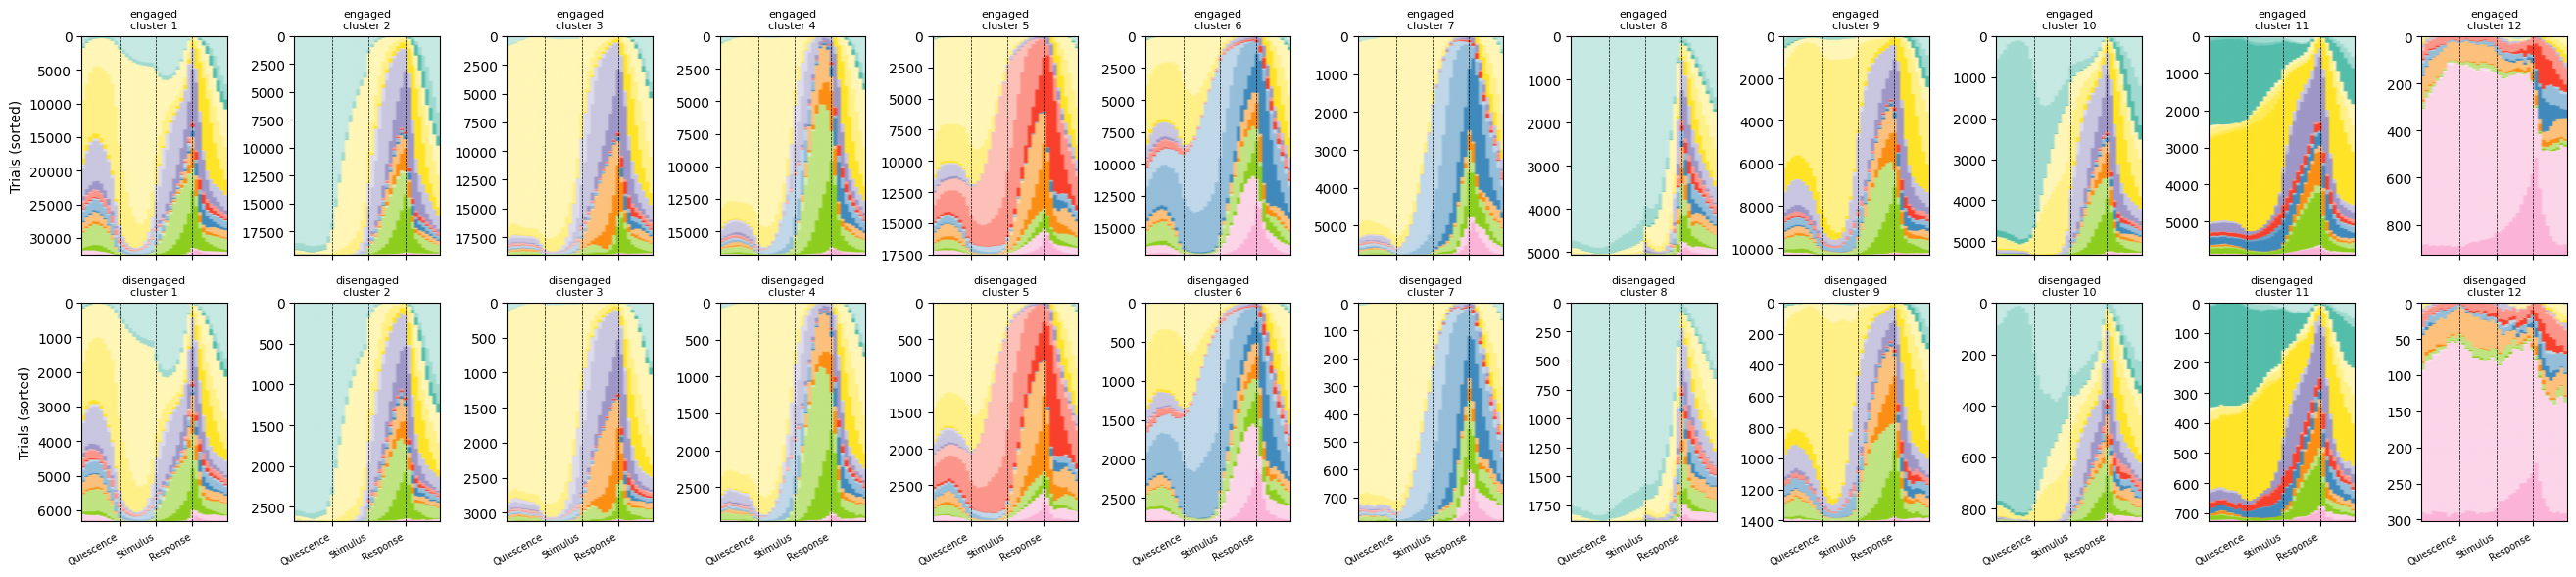

In [67]:
def build_mouse_seq(data, epochs=EPOCHS_TO_ANALYSE, n_bins=N_BINS_PER_EPOCH):
    """One row per trial (approx - assumes each trial contributes one row per epoch), one column
    per (epoch, time-bin); rows sorted for visual grouping, same approach as the original notebook."""
    bound = int(len(data) / len(epochs))
    if bound == 0:
        return None
    mat = np.full((bound, n_bins * len(epochs)), np.nan)
    for e, epoch in enumerate(epochs):
        epoch_data = np.vstack(data.loc[data['broader_label'] == epoch, 'binned_sequence'].values)[:bound, :]
        mat[:epoch_data.shape[0], n_bins * e:n_bins * (e + 1)] = raw_to_grouped_code(epoch_data)
    return np.sort(mat, axis=0)


def plot_fingerprint_row(sequences_df, cluster_ids, axes_row, row_label):
    for ax, cluster_id in zip(axes_row, cluster_ids):
        mat = build_mouse_seq(sequences_df[sequences_df['trial_cluster'] == cluster_id])
        if mat is None:
            ax.axis('off')
            continue
        ax.imshow(mat, aspect='auto', cmap=paw_state_palette, vmin=0, vmax=31, interpolation=None)
        for x in (10, 20, 30):
            ax.axvline(x=x, color='k', linestyle='--', linewidth=0.5)
        ax.set_title(f'{row_label}\ncluster {int(cluster_id)}', fontsize=8)
        ax.set_xticks([10, 20, 30])
        ax.set_xticklabels(['Quiescence', 'Stimulus', 'Response'], rotation=30, ha='right', fontsize=7)


cluster_ids = sorted(sequences['trial_cluster'].dropna().unique())
fig, axes = plt.subplots(2, len(cluster_ids), figsize=(2.2 * len(cluster_ids), 6), sharex=True)
for row, state in enumerate(['engaged', 'disengaged']):
    plot_fingerprint_row(sequences[sequences['dominant_state'] == state], cluster_ids, axes[row], state)
axes[0, 0].set_ylabel('Trials (sorted)')
axes[1, 0].set_ylabel('Trials (sorted)')
plt.tight_layout()
plt.show()


## Which trial modes distinguish engaged from disengaged? Does it vary by animal, and along LDA 1?

Per session, per cluster: `discrimination = occupancy(engaged) - occupancy(disengaged)` (positive = that trial mode is used more when engaged, negative = more when disengaged). Restricted to `FOCUS_FILE` (`17_trial_waterclust`) for consistency with the state-switching section above.

In [ ]:
occ_wide = occ[FOCUS_FILE].pivot_table(index=['eid', 'trial_cluster'], columns='dominant_state',
                                        values='occupancy', fill_value=0)
occ_wide = occ_wide.reindex(columns=['engaged', 'disengaged'], fill_value=0)
occ_wide['discrimination'] = occ_wide['engaged'] - occ_wide['disengaged']
occ_wide = occ_wide.reset_index()

lda_lookup_focus = merged[FOCUS_FILE][['eid', 'lda_1']].drop_duplicates('eid')
occ_wide = occ_wide.merge(lda_lookup_focus, on='eid', how='left')

cluster_ranking = (occ_wide.groupby('trial_cluster')['discrimination']
                    .agg(mean_signed='mean', mean_abs=lambda s: s.abs().mean(), sem='sem', n_sessions='count')
                    .reset_index()
                    .sort_values('mean_abs', ascending=False))
print(cluster_ranking.round(4).to_string(index=False))


### Ranking: which modes are most diagnostic of engagement, on average

In [ ]:
ranking_sorted = cluster_ranking.sort_values('mean_abs', ascending=False)
colors = ['tab:blue' if v >= 0 else 'tab:orange' for v in ranking_sorted['mean_signed']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ranking_sorted['trial_cluster'].astype(int).astype(str), ranking_sorted['mean_signed'],
       yerr=ranking_sorted['sem'], color=colors)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Trial cluster (ranked by |discrimination|, most to least)')
ax.set_ylabel('Mean occupancy(engaged) - occupancy(disengaged)')
ax.set_title('Blue = more used when engaged, orange = more used when disengaged')
plt.tight_layout()
plt.show()


### Per-session/animal variability, sorted by LDA 1

Rows = sessions (sorted by LDA 1, low to high, top to bottom), columns = trial cluster, color = discrimination score. Shows both how much this varies session-to-session/animal-to-animal, and whether any visible band or gradient tracks LDA 1.

In [ ]:
heat_data = occ_wide.pivot_table(index='eid', columns='trial_cluster', values='discrimination')
session_lda_order = (occ_wide[['eid', 'lda_1']].drop_duplicates().dropna(subset=['lda_1'])
                      .sort_values('lda_1')['eid'])
heat_data = heat_data.reindex(session_lda_order)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heat_data, cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'engaged - disengaged occupancy'})
ax.set_xlabel('Trial cluster')
ax.set_ylabel('Session (sorted by LDA 1: low at top, high at bottom)')
ax.set_yticks([])
plt.tight_layout()
plt.show()


### Does any specific mode's discriminating power itself track LDA 1?

In [ ]:
from statsmodels.stats.multitest import multipletests

cluster_lda_rows = []
for cluster, g in occ_wide.dropna(subset=['lda_1']).groupby('trial_cluster'):
    if len(g) < 20:
        continue
    r_p, p_p = pearsonr(g['lda_1'], g['discrimination'])
    r_s, p_s = spearmanr(g['lda_1'], g['discrimination'])
    cluster_lda_rows.append({'trial_cluster': cluster, 'n_sessions': len(g),
                              'pearson_r': r_p, 'pearson_p': p_p, 'spearman_r': r_s, 'spearman_p': p_s})

cluster_lda_corr = pd.DataFrame(cluster_lda_rows).sort_values('pearson_p')
_, p_fdr, _, _ = multipletests(cluster_lda_corr['pearson_p'], method='fdr_bh')
cluster_lda_corr['p_fdr_bh'] = p_fdr
print(cluster_lda_corr.round(4).to_string(index=False))


In [ ]:
top_clusters = cluster_lda_corr.head(3)['trial_cluster'].tolist()
fig, axes = plt.subplots(1, len(top_clusters), figsize=(5.5 * len(top_clusters), 4.5))
for ax, cluster in zip(np.atleast_1d(axes), top_clusters):
    sub = occ_wide[occ_wide['trial_cluster'] == cluster].dropna(subset=['lda_1'])
    x, y = sub['lda_1'], sub['discrimination']
    r, p = pearsonr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel(f'Cluster {int(cluster)}\nengaged - disengaged occupancy')
    ax.set_title(f"Pearson r={r:.2f} (p={p:.3f})", fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


## Are some trial modes more common during uncertain engagement-state estimates?

Per trial mode (cluster): the mean and variance of `p_state1` itself (does this mode skew toward one state or the other?), and separately the mean and variance of *confidence* = `max(p_state1, p_state2)` (how decisively classified are trials in this mode, regardless of which state they lean toward?).

These aren't the same thing: a mode used by a roughly 50/50 mix of confidently-engaged and confidently-disengaged trials would show high variance in `p_state1` but *high* mean confidence (each individual trial is still decisively classified - the mode is just used in both states). A mode where individual trials genuinely sit near 0.5 would show *low* mean confidence - that's real per-trial ambiguity. `confidence` is the one that actually answers "is this mode common during uncertain estimates."

In [ ]:
merged_focus = merged[FOCUS_FILE].copy()
merged_focus['confidence'] = np.maximum(merged_focus['p_state1'], merged_focus['p_state2'])

cluster_posterior_stats = (merged_focus.groupby('trial_cluster')
                            .agg(mean_p_state1=('p_state1', 'mean'),
                                 var_p_state1=('p_state1', 'var'),
                                 mean_confidence=('confidence', 'mean'),
                                 var_confidence=('confidence', 'var'),
                                 n_trials=('p_state1', 'size'))
                            .reset_index()
                            .sort_values('mean_confidence'))
print(cluster_posterior_stats.round(4).to_string(index=False))


### Mean posterior confidence per trial mode

In [ ]:
sorted_stats = cluster_posterior_stats.sort_values('mean_confidence')
sem_confidence = (merged_focus.groupby('trial_cluster')['confidence'].sem()
                   .reindex(sorted_stats['trial_cluster']).values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sorted_stats['trial_cluster'].astype(int).astype(str), sorted_stats['mean_confidence'],
       yerr=sem_confidence, color='tab:purple', alpha=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance (fully ambiguous)')
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Trial cluster (sorted, most uncertain first)')
ax.set_ylabel('Mean posterior confidence: max(p_state1, p_state2)')
ax.set_title('Which trial modes have more uncertain engagement-state estimates?')
ax.legend()
plt.tight_layout()
plt.show()


### Full distribution, not just the mean

Violin of `p_state1` per mode (same sort order) - shows whether a mode's spread comes from genuine mid-range ambiguity (mass piled up near 0.5) or from a bimodal mix of confidently-opposite trials (two separated peaks near 0 and 1).

In [ ]:
order = sorted_stats['trial_cluster'].astype(int).tolist()
plot_df = merged_focus.assign(trial_cluster=merged_focus['trial_cluster'].astype(int))

fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=plot_df, x='trial_cluster', y='p_state1', order=order, ax=ax, cut=0, inner='quartile')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Trial cluster (sorted by mean confidence, most uncertain first)')
ax.set_ylabel('Posterior P(state1)')
plt.tight_layout()
plt.show()


## Is disengagement a tighter, more stereotyped subtrial signature for high-LDA-1 mice?

Candidate mechanistic explanation for why low-LDA-1 mice show more switchy, less confidently-classified engagement: maybe their disengaged behavior isn't one consistent movement style - just a diffuse grab-bag of different ways of not-engaging - while high-LDA-1 mice disengage in a single, stereotyped way. Tests this directly with continuous subtrial features (same PCA representation validated in `3_trial_modes/subtrial_hmm_pilot.ipynb`), not discretized trial-cluster labels.

Per session: PCA-project every trial's subtrial syllable sequence into one shared, globally-fit space (fit once, applied to every session, so "tight" and "diffuse" mean the same thing everywhere), then measure the spread (mean distance to centroid) of disengaged trials and, separately, of engaged trials, within that session.

In [ ]:
from sklearn.decomposition import PCA

EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
N_BINS = 10
N_CODES = 32  # raw binned_sequence codes are 0-31


def build_design_matrix(sub_seq):
    """One row per trial, one-hot encoded across all 4*10=40 (epoch, bin) positions x 32 codes -
    same construction as clustering_trial_syllables_watershed.ipynb's own PCA step."""
    wide = sub_seq.pivot_table(index='sample', columns='broader_label', values='binned_sequence', aggfunc='first')
    wide = wide.dropna(subset=EPOCHS)
    n = len(wide)
    X = np.zeros((n, len(EPOCHS) * N_BINS * N_CODES), dtype=np.float32)
    valid = np.ones(n, dtype=bool)
    for e, epoch in enumerate(EPOCHS):
        arr = np.vstack(wide[epoch].values)
        bad = np.isnan(arr).any(axis=1)
        valid &= ~bad
        codes = np.clip(np.nan_to_num(arr, nan=0).astype(int), 0, N_CODES - 1)
        for b in range(N_BINS):
            X[np.arange(n), (e * N_BINS + b) * N_CODES + codes[:, b]] = 1.0
    return wide.index[valid].values, X[valid]


N_PCA_COMPONENTS = 30
PCA_FIT_SAMPLE_SIZE = 30000

rng = np.random.default_rng(0)
pca_fit_sample_ids = rng.choice(all_sequences['sample'].unique(),
                                 size=min(PCA_FIT_SAMPLE_SIZE, all_sequences['sample'].nunique()),
                                 replace=False)
_, X_pca_fit = build_design_matrix(all_sequences[all_sequences['sample'].isin(pca_fit_sample_ids)])

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0)
pca.fit(X_pca_fit)
print(f"PCA fit on {X_pca_fit.shape[0]} trials | {N_PCA_COMPONENTS} components explain "
      f"{np.cumsum(pca.explained_variance_ratio_)[-1]:.1%} variance")


### Project every trial through the (fixed) global PCA, attach engagement state and LDA 1

In [ ]:
all_trial_samples, X_all = build_design_matrix(all_sequences)
X_all_pca = pca.transform(X_all)

pca_cols = [f'pc{i}' for i in range(N_PCA_COMPONENTS)]
subtrial_features = pd.DataFrame(X_all_pca, columns=pca_cols)
subtrial_features['session'] = [s.split()[0] for s in all_trial_samples]
subtrial_features['trial_id'] = [float(s.split()[1]) for s in all_trial_samples]

subtrial_trials = subtrial_features.merge(
    states_df[['eid', 'trial_id', 'dominant_state', 'lda_1']],
    left_on=['session', 'trial_id'], right_on=['eid', 'trial_id'], how='inner')
print(f"{len(subtrial_trials)} trials with both subtrial-PCA features and a validated engagement "
      f"label, across {subtrial_trials['session'].nunique()} sessions")


### Per-session spread (mean distance to centroid), separately for engaged and disengaged trials

In [ ]:
MIN_TRIALS_PER_STATE = 20


def compute_spread(group):
    vals = group[pca_cols].values
    centroid = vals.mean(axis=0)
    return np.linalg.norm(vals - centroid, axis=1).mean()


spread_rows = []
for (session, state), g in subtrial_trials.groupby(['session', 'dominant_state']):
    if len(g) < MIN_TRIALS_PER_STATE:
        continue
    spread_rows.append({'session': session, 'dominant_state': state,
                         'spread': compute_spread(g), 'n_trials': len(g)})

spread_df = pd.DataFrame(spread_rows)
spread_wide = spread_df.pivot(index='session', columns='dominant_state', values='spread')
spread_wide = spread_wide.dropna(subset=['engaged', 'disengaged'])
spread_wide['asymmetry'] = spread_wide['disengaged'] - spread_wide['engaged']

lda_lookup_all = states_df[['eid', 'lda_1']].drop_duplicates('eid').rename(columns={'eid': 'session'})
spread_wide = spread_wide.reset_index().merge(lda_lookup_all, on='session', how='left').dropna(subset=['lda_1'])
print(f"{len(spread_wide)} sessions with >= {MIN_TRIALS_PER_STATE} trials in both states, and LDA 1")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, label in [(axes[0], 'disengaged', 'Disengaged-trial spread\n(subtrial PCA space)'),
                        (axes[1], 'engaged', 'Engaged-trial spread\n(subtrial PCA space)'),
                        (axes[2], 'asymmetry', 'Disengaged - engaged spread\n(asymmetry)')]:
    x, y = spread_wide['lda_1'], spread_wide[col]
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel(label)
    ax.set_title(f"Pearson r={r_p:.2f} (p={p_p:.3f})\nSpearman r={r_s:.2f} (p={p_s:.3f})", fontsize=8.5)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()

print(f"n sessions = {len(spread_wide)}")


## Raw syllable-use entropy (not trial-mode entropy, not PCA distance)

Sidesteps both earlier concerns - the discrete watershed clustering (an extra, somewhat arbitrary layer) and the PCA-distance "spread" metric (whose Euclidean-distance interpretation doesn't respect the known paw/whisk/lick similarity structure, and was never independently validated). This works directly on raw syllable codes (0-31) at each of the 40 (epoch, bin) positions - the same base data everything else derives from, no clustering or dimensionality reduction step in between.

Definition: for each of the 40 trial timepoints, the Shannon entropy of *which syllable code occurs there, across trials* (within a session, and - for the per-state version - within engaged or disengaged trials only), normalized by `log(32)`. Averaged across the 40 timepoints to get one number per session (or per session x state) - directly analogous to "trial mode entropy" above, just computed on raw syllables instead of on watershed cluster labels.

In [ ]:
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
N_BINS = 10
N_CODES = 32
MIN_TRIALS_PER_TIMEPOINT = 5

all_sequences_exp = all_sequences.copy()
all_sequences_exp['session'] = all_sequences_exp['sample'].str.split().str[0:1].str.join('')
all_sequences_exp['trial_id'] = all_sequences_exp['sample'].str.split().str[1:2].str.join('').astype(float)

all_sequences_exp = all_sequences_exp.merge(
    states_df[['eid', 'trial_id', 'dominant_state', 'lda_1']],
    left_on=['session', 'trial_id'], right_on=['eid', 'trial_id'], how='inner')

codes_matrix = np.vstack(all_sequences_exp['binned_sequence'].values)
for b in range(N_BINS):
    all_sequences_exp[f'bin{b}'] = codes_matrix[:, b]

long_df = all_sequences_exp.melt(
    id_vars=['session', 'trial_id', 'dominant_state', 'lda_1', 'broader_label'],
    value_vars=[f'bin{b}' for b in range(N_BINS)],
    var_name='bin_idx', value_name='code')
long_df['bin_idx'] = long_df['bin_idx'].str.replace('bin', '').astype(int)
epoch_order = {e: i for i, e in enumerate(EPOCHS)}
long_df['timepoint'] = long_df['broader_label'].map(epoch_order) * N_BINS + long_df['bin_idx']
long_df = long_df.dropna(subset=['code'])
print(f"{len(long_df)} (trial, timepoint) observations, {long_df['session'].nunique()} sessions")


def shannon_entropy(codes, n_categories=N_CODES):
    counts = np.bincount(codes.astype(int), minlength=n_categories)
    counts = counts[counts > 0]
    p = counts / counts.sum()
    return -(p * np.log(p)).sum()


### Per-state syllable-use entropy vs LDA 1

In [ ]:
entropy_rows = []
for (session, state, tp), g in long_df.groupby(['session', 'dominant_state', 'timepoint']):
    if len(g) < MIN_TRIALS_PER_TIMEPOINT:
        continue
    entropy_rows.append({'session': session, 'dominant_state': state, 'timepoint': tp,
                          'entropy': shannon_entropy(g['code'].values), 'n': len(g)})
entropy_df = pd.DataFrame(entropy_rows)

session_state_entropy = (entropy_df.groupby(['session', 'dominant_state'])
                          .agg(mean_entropy=('entropy', 'mean'), n_timepoints=('entropy', 'size'))
                          .reset_index())
session_state_entropy = session_state_entropy[session_state_entropy['n_timepoints'] >= 35]
session_state_entropy['normalized_entropy'] = session_state_entropy['mean_entropy'] / np.log(N_CODES)

lda_lookup_all = states_df[['eid', 'lda_1']].drop_duplicates('eid').rename(columns={'eid': 'session'})
session_state_entropy = session_state_entropy.merge(lda_lookup_all, on='session', how='left').dropna(subset=['lda_1'])

for state in ['engaged', 'disengaged']:
    sub = session_state_entropy[session_state_entropy['dominant_state'] == state]
    r_p, p_p = pearsonr(sub['lda_1'], sub['normalized_entropy'])
    r_s, p_s = spearmanr(sub['lda_1'], sub['normalized_entropy'])
    print(f"{state}: n={len(sub)} sessions | Pearson r={r_p:.3f} (p={p_p:.4f}) | "
          f"Spearman r={r_s:.3f} (p={p_s:.4f})")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, state in zip(axes, ['engaged', 'disengaged']):
    sub = session_state_entropy[session_state_entropy['dominant_state'] == state]
    x, y = sub['lda_1'], sub['normalized_entropy']
    r, p = pearsonr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel(f'{state}\nnormalized syllable-use entropy')
    ax.set_title(f"Pearson r={r:.2f} (p={p:.3f})", fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


### State-independent syllable-use entropy vs LDA 1

In [ ]:
entropy_overall_rows = []
for (session, tp), g in long_df.groupby(['session', 'timepoint']):
    if len(g) < MIN_TRIALS_PER_TIMEPOINT:
        continue
    entropy_overall_rows.append({'session': session, 'timepoint': tp,
                                  'entropy': shannon_entropy(g['code'].values), 'n': len(g)})
entropy_overall_df = pd.DataFrame(entropy_overall_rows)

session_entropy_overall = (entropy_overall_df.groupby('session')
                            .agg(mean_entropy=('entropy', 'mean'), n_timepoints=('entropy', 'size'))
                            .reset_index())
session_entropy_overall = session_entropy_overall[session_entropy_overall['n_timepoints'] >= 35]
session_entropy_overall['normalized_entropy'] = session_entropy_overall['mean_entropy'] / np.log(N_CODES)
session_entropy_overall = session_entropy_overall.merge(lda_lookup_all, on='session', how='left').dropna(subset=['lda_1'])

r_p, p_p = pearsonr(session_entropy_overall['lda_1'], session_entropy_overall['normalized_entropy'])
r_s, p_s = spearmanr(session_entropy_overall['lda_1'], session_entropy_overall['normalized_entropy'])
print(f"state-independent: n={len(session_entropy_overall)} sessions | Pearson r={r_p:.3f} (p={p_p:.4f}) | "
      f"Spearman r={r_s:.3f} (p={p_s:.4f})")


In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
x, y = session_entropy_overall['lda_1'], session_entropy_overall['normalized_entropy']
r, p = pearsonr(x, y)
sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=25)
a, b = np.polyfit(x, y, 1)
x_range = np.linspace(x.min(), x.max(), 100)
ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)
ax.set_xlabel('LDA 1')
ax.set_ylabel('Normalized syllable-use entropy\n(state-independent)')
ax.set_title(f"Pearson r={r:.2f} (p={p:.3f})", fontsize=9)
fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()


## Notes / caveats

- First exploratory pass only - no multiple-comparisons correction, no per-mouse aggregation yet.
- Uses the currently saved cluster files (`12_`/`17_`/`22_trial_waterclust`, `all_sequences_26-03-2026` vintage) and `mouse_LDA_5_bins_cut19-06-2026`; not the older `21_`/`24_trial_waterclust` files, which come from a different (smaller) trial-sequence snapshot.
- `engaged`/`disengaged` labeling of `state1`/`state2` is a working assumption carried over from `load_states.ipynb`, not independently re-validated here.
- Rerun end-to-end once the pipeline produces updated trial-cluster / LDA / states files - update `CLUSTER_FILES` and the LDA/states filenames above.
- `build_mouse_seq`'s trial count (`len(data) / len(epochs)`) is an approximation carried over from `fingerprint_analyses_mice.ipynb` - it assumes every trial contributes exactly one row per epoch, which can be slightly off if some trials are missing an epoch.
- `TRIAL_FILE`/`SEQUENCES_FILE` auto-fall back to older local vintages if the primary path isn't cached on this machine (see `first_existing`) - watch the printed filename/warning, since the fallback `SEQUENCES_FILE` pairs with `21_`/`24_trial_waterclust`, not `12_`/`17_`/`22_`.
- The "State switching and trial clusters" section is restricted to `FOCUS_FILE = '17_trial_waterclust'` only, since that's the resolution where the entropy effects showed up - not yet checked at 12/22 clusters.
- The partial-correlation confound check found the engaged-vs-disengaged *divergence* effect is fully explained by switching frequency (n_transitions), but the entropy effects (engaged-trial and state-independent) are not - worth keeping that distinction when writing this up.
- Trial-cluster stickiness uses a per-session shuffle null (200 permutations) to correct for base-rate cluster imbalance; only the sign/significance were checked here, not whether 200 shuffles is enough for a stable null estimate at the tails.